<a href="https://colab.research.google.com/github/mikolajbaraniak-3232/lecture1/blob/main/pum5_regresjanieliniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [2]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_7203/2150386848.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 18.9k/18.9k [00:00<00:00, 13.1MB/s]

First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [3]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

In [4]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Zbuduj model benchmarkowy - zwykłą regresję liniową

In [5]:
regressor = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressor.coef_}")
print(f"Wyraz wolny: {regressor.intercept_}")
print(f" R^2 {regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny z treningu: {mean_absolute_error(y_train, regressor.predict(X_train)):.2f}")

y_pred = regressor.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred):.2f}")

Współczynniki: [ 3400.65625     7384.17507075 15289.75305615    38.30848175
  2155.12465162]
Wyraz wolny: -63972.08387966572
 R^2 0.9043289032978942
Średni błąd absolutny z treningu: 11171.01
Średni błąd kwadratowy: 252493731.92
Średni błąd absolutny: 11377.18
Wyjaśniona wariancja: 0.89


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(X)
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("VIF:")
print(vif_data)

VIF:
               feature         VIF
0                const  366.936239
1                  Age   25.071159
2               Gender    1.018941
3      Education Level    1.564464
4            Job Title    1.024344
5  Years of Experience   26.277519


Spróbuj poprawić wynik używając regresji LASSO

In [10]:
lasso_regressor = Lasso(alpha=100.0)
lasso_regressor.fit(X_train, y_train)

print(f"Współczynniki (Lasso): {lasso_regressor.coef_}")
print(f"Wyraz wolny (Lasso): {lasso_regressor.intercept_}")
print(f"R^2 (Lasso na treningu): {lasso_regressor.score(X_train, y_train):.2f}")
print(f"Średni błąd absolutny z treningu (Lasso): {mean_absolute_error(y_train, lasso_regressor.predict(X_train)):.2f}")

y_pred_lasso = lasso_regressor.predict(X_test)
print(f"Średni błąd kwadratowy (Lasso): {mean_squared_error(y_test, y_pred_lasso):.2f}")
print(f"Średni błąd absolutny (Lasso): {mean_absolute_error(y_test, y_pred_lasso):.2f}")
print(f"Wyjaśniona wariancja (Lasso): {explained_variance_score(y_test, y_pred_lasso):.2f}")
print(f"R^2 (Lasso na tescie): {r2_score(y_test, y_pred_lasso):.2f}")

Współczynniki (Lasso): [ 3394.18432067  6965.78348124 14982.37123399    38.46557392
  2181.36484803]
Wyraz wolny (Lasso): -63645.58227087073
R^2 (Lasso na treningu): 0.90
Średni błąd absolutny z treningu (Lasso): 11151.89
Średni błąd kwadratowy (Lasso): 252146404.84
Średni błąd absolutny (Lasso): 11344.59
Wyjaśniona wariancja (Lasso): 0.89
R^2 (Lasso na tescie): 0.89


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


In [11]:
df['Years_Exp_Squared'] = df['Years of Experience'] ** 2

print(df[['Years of Experience', 'Years_Exp_Squared']].head())

   Years of Experience  Years_Exp_Squared
0                  5.0               25.0
1                  3.0                9.0
2                 15.0              225.0
3                  7.0               49.0
4                 20.0              400.0


In [12]:
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_poly = Lasso(alpha=500.0)
lasso_poly.fit(X_train_scaled, y_train)

print(f"R^2 na teście (po dodaniu kwadratu): {lasso_poly.score(X_test_scaled, y_test):.4f}")
print(f"MAE (Średni błąd): {mean_absolute_error(y_test, lasso_poly.predict(X_test_scaled)):.2f}")

R^2 na teście (po dodaniu kwadratu): 0.8885
MAE (Średni błąd): 11348.37


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

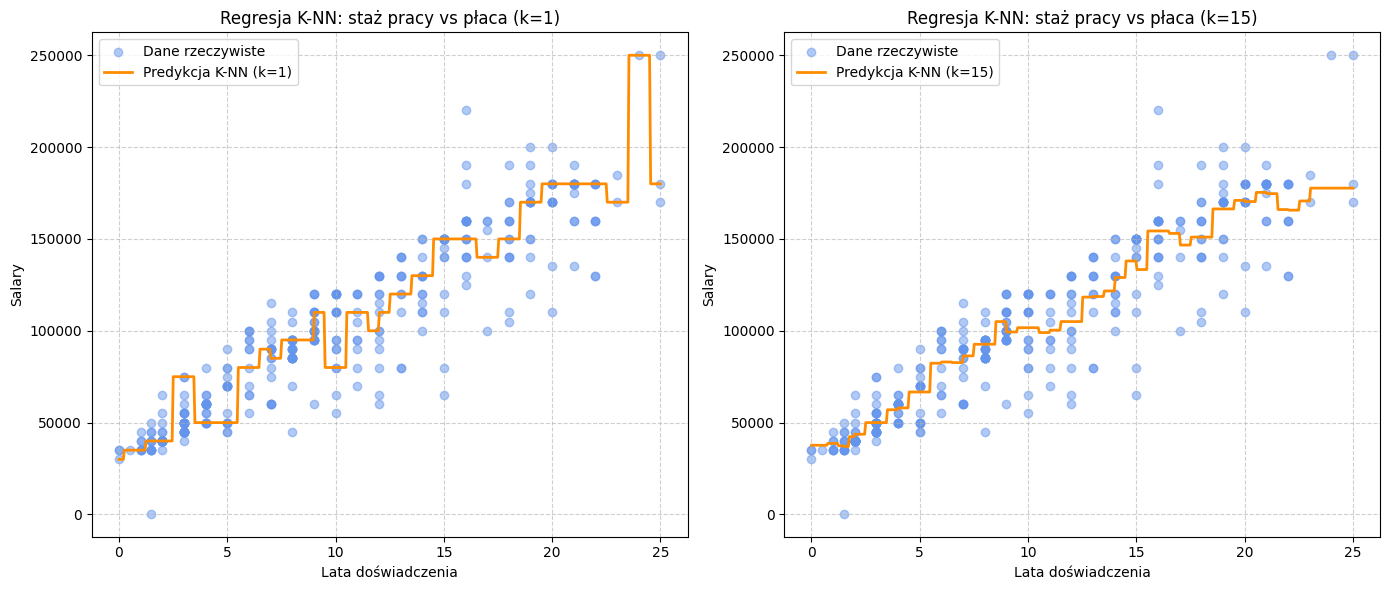

CZY REGRESJA WYŻSZEGO RZĘDU JEST UZASADNIONA?
Patrząc na powyższy wykres to nie. Dane układają się w sposób liniowy, regresja wyższego rzędu  mogłaby niepotrzebnie próbować wyginać linię


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

X_vis = df[['Years of Experience']].values
y_vis = df['Salary'].values
idx = X_vis.flatten().argsort()
X_vis = X_vis[idx]
y_vis = y_vis[idx]

T = np.linspace(X_vis.min(), X_vis.max(), 500).reshape(-1, 1)

n_neighbors_1 = 1
n_neighbors_2 = 15

knn_1 = KNeighborsRegressor(n_neighbors_1)
knn_2 = KNeighborsRegressor(n_neighbors_2)

plt.figure(figsize=(14, 6))

for i, (k, label) in enumerate([(n_neighbors_1, 'K=1 (Uniform)'), (n_neighbors_2, 'K=15 (Uniform)')]):
    plt.subplot(1, 2, i + 1)

    knn = KNeighborsRegressor(n_neighbors=k)
    y_pred = knn.fit(X_vis, y_vis).predict(T)

    plt.scatter(X_vis, y_vis, color="cornflowerblue", label="Dane rzeczywiste", alpha=0.5)
    plt.plot(T, y_pred, color="darkorange", label=f"Predykcja K-NN (k={k})", linewidth=2)

    plt.title(f"Regresja K-NN: staż pracy vs płaca (k={k})")
    plt.xlabel("Lata doświadczenia")
    plt.ylabel("Salary")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# --- ODPOWIEDŹ NA PYTANIE ---
print("CZY REGRESJA WYŻSZEGO RZĘDU JEST UZASADNIONA?")
print("Patrząc na powyższy wykres to nie. Dane układają się w sposób liniowy, regresja wyższego rzędu  mogłaby niepotrzebnie próbować wyginać linię.")
